# cds_v3

Here we take VST + quantile normalised data and convert to Level 4, then Level 5 consensus data

Level 4 will be calculated using median and/or MAD

Level 5 will be calculated using R limma package and then reimported

# Packages

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# Directories

In [3]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'

OUTPUT = 'D:/DDesktop/_work/data/canada/output/'
TABULAR = OUTPUT + 'tabular/'
LOG = OUTPUT + 'transform_log/'
CPM = OUTPUT + 'transform_logcpm/'
VST = OUTPUT + 'transform_vst/'
QNT = OUTPUT + 'transform_quantile/'

# Functions

# logCPM analysis

In [56]:
# Load logCPM data
df = pd.read_csv(CPM + '6h_logcpm_landmark.csv', index_col = 0)
# Get list of control columns
list_controls = [column for column in df.columns if 'vehicle' in column]
list_treatment = [column for column in df.columns if 'inf_halo' in column]
# Isolate data
df = df[list_controls + list_treatment]
# Show data
df.head()

,6h_inf_vehicle_1,6h_inf_vehicle_2,6h_inf_vehicle_3,6h_inf_halo_1,6h_inf_halo_2,6h_inf_halo_3
gene_symbol,,,,,,
DFFB,2.362422,2.358900,2.497295,2.037299,2.029936,2.086653
ICMT,7.434182,7.486369,7.519884,6.504115,6.658988,6.688392
KLHL21,6.155833,5.942884,6.283776,7.740650,7.943831,8.067412
CLSTN1,7.785701,7.796839,8.035360,7.556359,7.772797,7.832019
DFFA,6.896466,7.000015,7.051716,6.249811,6.115616,6.260845


In [74]:
def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

list_to_file(OUTPUT + 'lm_names.txt', df.index)
print(len(df.index))

901


In [ ]:
# Compute reference distribution
controls = df[[column for column in df.columns if 'vehicle' in column]]
control_values = controls.values

# Create reference distribution
ref_dist = np.mean(np.sort(control_values, axis = 0), axis = 1)

def quantile_normalize(df, reference):
    ranked = np.argsort(np.argsort(df.values, axis=0), axis=0)
    out = np.zeros_like(df.values)
    for col in range(df.shape[1]):
        out[ranked[:, col], col] = reference
    return pd.DataFrame(out, index=df.index, columns=df.columns)

df_quantile = quantile_normalize(df, ref_dist)

# Show data
df_quantile.head()

,6h_inf_vehicle_1,6h_inf_vehicle_2,6h_inf_vehicle_3,6h_inf_halo_1,6h_inf_halo_2,6h_inf_halo_3
gene_symbol,,,,,,
DFFB,11.874072,0.000000,10.318709,11.874072,11.874072,11.874072
ICMT,10.318709,10.318709,11.874072,10.318709,8.601021,9.070641
KLHL21,8.121805,5.071045,8.121805,9.580998,9.096191,8.601021
CLSTN1,8.054448,5.395375,8.054448,8.121805,9.070641,9.096191
DFFA,5.395375,9.096191,4.922910,5.071045,7.528992,8.121805


In [61]:
# Control median
control_median = df_quantile[list_controls].median(axis = 1)
# Control MAD
control_mad = (df_quantile[list_controls]
               .sub(control_median, axis=0)
               .abs()
               .median(axis=1))
               
# global MAD used as floor
global_mad = (df_quantile
              .sub(df_quantile.median(axis=1), axis=0)
              .abs()
              .median(axis=1))

threshold = 0.1 * global_mad
effective_mad = control_mad.clip(lower=threshold)  # LINCS-style MAD floor

df_l4 = pd.DataFrame(index=df_quantile.index)

for col in list_treatment:
    df_l4[col + "_L4"] = (df_quantile[col] - control_median) / (1.4826 * effective_mad)

# Show data
df_l4.head()

,6h_inf_halo_1_L4,6h_inf_halo_2_L4,6h_inf_halo_3_L4
gene_symbol,,,
DFFB,0.674491,0.674491,0.674491
ICMT,0.000000,-18.565738,-13.489815
KLHL21,20.201690,13.489815,6.634468
CLSTN1,0.894146,13.489815,13.828984
DFFA,-0.463014,3.045952,3.892252


In [71]:
list_all = []

for column in df_l4.columns:
    df_slice = df_l4[df_l4[column] > 30]
    list_index = list(df_slice.index)
    list_all.extend(list_index)

list_all = list(set(list_all))
print(len(list_all))
list_all

18


['SNX13',
 'PSMF1',
 'TRAPPC3',
 'CLTB',
 'TXLNA',
 'INPP4B',
 'NUDT9',
 'RPP38',
 'PPP1R13B',
 'HPRT1',
 'CEBPD',
 'CCNF',
 'COG4',
 'RFX5',
 'TBXA2R',
 'CAPN1',
 'CYCS',
 'NCK2']

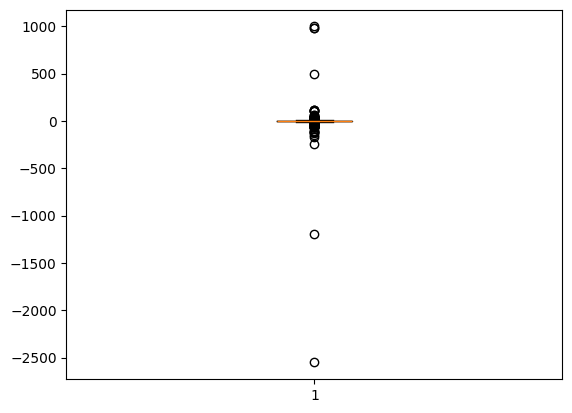

In [64]:
plt.boxplot(df_l4.values.ravel('K'));

In [65]:
# Convert to matrix of values
Z = df_l4.values
# Compute pairwise Spearman correlation between replicates
corr_matrix, _ = spearmanr(Z, axis = 0)
# Extract replicate x replicate values
R = df_l4.shape[1]
corr_matrix = corr_matrix[:R, :R]
# Zero self-correlations
np.fill_diagonal(corr_matrix, 0)
# Compute weights as sum of correlations for each replicate
weights = corr_matrix.sum(axis = 0)
# Normalise weights to sum to 1
weights = weights / weights.sum()
# Compute MODZ as weighted average of replicate vectors
modz = np.dot(Z, weights)
# Check results
results = pd.Series(modz, index = df_l4.index, name = 'modz')
# Show data
results

gene_symbol
DFFB         0.674491
ICMT       -10.959667
KLHL21      13.379219
CLSTN1       9.574664
DFFA         2.202699
              ...    
HPRT1       34.527670
HTATSF1    -15.913830
MAMLD1    -386.061616
NSDHL     -905.971027
LAGE3      -13.489815
Name: modz, Length: 901, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1899c4f5d80>,
 'caps': [<matplotlib.lines.Line2D at 0x1899c4f6170>,
 'boxes': [<matplotlib.lines.Line2D at 0x1899c4f5450>],
 'medians': [<matplotlib.lines.Line2D at 0x1899c4f6650>],
 'fliers': [<matplotlib.lines.Line2D at 0x1899c4f7fd0>],
 'means': []}

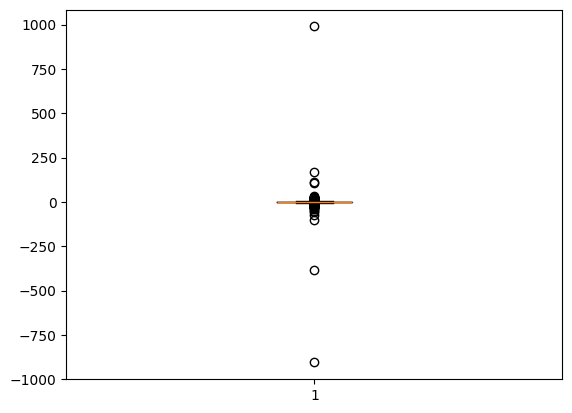

In [66]:
plt.boxplot(results)

In [ ]:
# TODO
# Check follow up response from GPT to access LINCS reference supplied by BROAD for normalisation just in case
# Check what this phrase means in the paper: Level 3 L1000 data were used, and the GTEx RNA-seq data were quantile normalized, log2 scaled 1+RPKM values
# Need code which calculates MODZ values for 3 treaments
# Need code which applies MODZ values to graph
# Find code to pull from original LINCS Level 5 data
# Apply to cds graph
# Run embedding on max graph data

# Analysis

## Normalised Data

In [26]:
# Import data file
df = pd.read_csv(QNT + '6h_vst_quantile_normalized.csv', index_col = 0)
# Format column names
for column in df.columns:
    new_column = column.replace('X', '')
    df.rename(columns = {column : new_column}, inplace = True)
# Get list of control columns
list_controls = [column for column in df.columns if 'vehicle' in column]
list_treatment = [column for column in df.columns if 'inf_halo' in column]
# Isolate data
df = df[list_controls + list_treatment]
# Show data
df.head()

,6h_inf_vehicle_3,6h_inf_vehicle_2,6h_inf_vehicle_1,6h_inf_halo_3,6h_inf_halo_2,6h_inf_halo_1
DFFB,6.811178,6.738030,6.811178,6.366776,6.251829,6.417833
ICMT,11.960619,11.940242,11.888693,11.267630,11.241759,11.071278
KLHL21,10.698264,10.345116,10.602190,12.436512,12.319075,12.222812
CLSTN1,12.486358,12.265712,12.265712,12.242252,12.181245,12.014245
DFFA,11.469357,11.408048,11.296265,10.804688,10.626770,10.813723


## Level 4 Values

In [52]:
# Calculate median of controls
control_median = df[list_controls].median(axis = 1)
# Calculate MAD per gene
control_mad = (df[list_controls].sub(control_median, axis = 0).abs().median(axis = 1))

# # Calculate MAD floor across gene controls
# global_mad = (df[list_controls].sub(df[list_controls].median(axis = 1), axis = 0).abs().median(axis = 1))
# # Define minimum allowed MAD per gene
# effective_mad = control_mad.copy()
# threshold = 0.1 * global_mad
# too_small = effective_mad < threshold
# effective_mad[too_small] = global_mad[too_small]

# Calculate MAD floor across all genes and controls
absdev = df[list_controls].sub(control_median, axis = 0).abs()
mad_floor = absdev.median().median()
#mad_floor = absdev.median(axis = 1).quantile()
#mad_floor = absdev.median(axis=1).median()
#mad_floor = 0.05
# Set threshold
threshold = 0.1 * mad_floor
# Calculate effective MAD per gene
effective_mad = control_mad.clip(lower = threshold)
effective_mad = control_mad.clip(lower = mad_floor)

# Add small value to avoid DIV/0
#control_mad.replace(0, 1e-6, inplace = True)

# Calculate Level 4 Z-scores
for column in list_treatment:
    df[column + '_L4'] = (df[column] - control_median) / (1.4826 * effective_mad)
# Show data
df.head()

,6h_inf_vehicle_3,6h_inf_vehicle_2,6h_inf_vehicle_1,6h_inf_halo_3,6h_inf_halo_2,6h_inf_halo_1,6h_inf_halo_3_L4,6h_inf_halo_2_L4,6h_inf_halo_1_L4
DFFB,6.811178,6.738030,6.811178,6.366776,6.251829,6.417833,-10.611023,-13.355636,-9.391930
ICMT,11.960619,11.940242,11.888693,11.267630,11.241759,11.071278,-16.060023,-16.677744,-20.748325
KLHL21,10.698264,10.345116,10.602190,12.436512,12.319075,12.222812,12.877832,12.053364,11.377554
CLSTN1,12.486358,12.265712,12.265712,12.242252,12.181245,12.014245,-0.560170,-2.016835,-6.004309
DFFA,11.469357,11.408048,11.296265,10.804688,10.626770,10.813723,-6.637868,-8.595236,-6.538470


2.3275798926565248 -6.254998595134122
15.201447624342494 -19.12886632682009


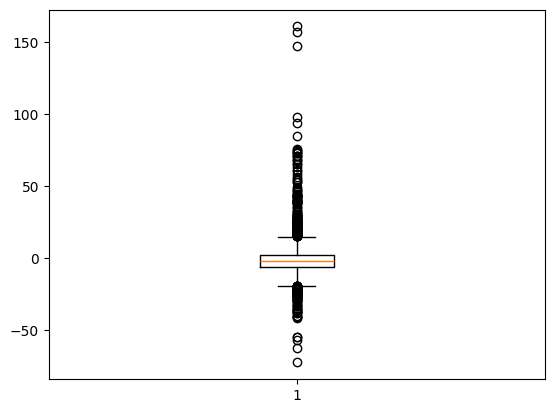

In [53]:
df_plot = df[[column for column in df.columns if 'L4' in column]]
list_values = df_plot.values.ravel('K')

# Calculate lower outlier
q1 = np.quantile(list_values, 0.25)
q3 = np.quantile(list_values, 0.75)
iqr = q3 - q1
uthreshold = q3 + (1.5 * iqr)
lthreshold = q1 - (1.5 * iqr)
print(q3, q1)
print(uthreshold, lthreshold)
plt.boxplot(list_values);

## Level 5 Values

In [32]:
# Extract level 4 values
df_l4 = df[[column for column in df.columns if 'L4' in column]]
# Convert to matrix of values
Z = df_l4.values
# Compute pairwise Spearman correlation between replicates
corr_matrix, _ = spearmanr(Z, axis = 0)
# Extract replicate x replicate values
R = df_l4.shape[1]
corr_matrix = corr_matrix[:R, :R]
# Zero self-correlations
np.fill_diagonal(corr_matrix, 0)
# Compute weights as sum of correlations for each replicate
weights = corr_matrix.sum(axis = 0)
# Normalise weights to sum to 1
weights = weights / weights.sum()
# Compute MODZ as weighted average of replicate vectors
modz = np.dot(Z, weights)
# Check results
results = pd.Series(modz, index = df_l4.index, name = 'modz')
# Show data
results

DFFB      -111.363181
ICMT       -24.688943
KLHL21      12.106414
CLSTN1     -28.414756
DFFA        -7.265640
              ...    
HPRT1       -7.576021
HTATSF1     -1.184484
MAMLD1      -6.299968
NSDHL        0.000000
LAGE3       -4.490174
Name: modz, Length: 945, dtype: float64